# B1 — Survey-Weighted Descriptive Analysis

Step 3 of the v2 protocol. Uses the frozen `df_model_v2.parquet` **read-only** —
this notebook does not alter that file. No predictive, propensity, or AIPW
models are fit here; every number below is a survey-weighted descriptive
statistic with a design-based confidence interval.

**Methodology, stated explicitly:** weighted prevalence is `sum(w*y)/sum(w)`
using `sample_weight_normalized`. Uncertainty uses **Taylor-series
linearization with the "ultimate cluster" approximation** — the standard
method DHS itself uses for sampling errors (treating PSUs as sampled with
replacement within strata, ignoring the finite population correction, which
is negligible at this scale). `cluster_number` is used as the PSU and
`sample_stratum_v022` as the stratum (confirmed identical to `v023` in Step
2; either is usable numerically, but the officially-documented one should be
cited by name in the eventual manuscript). For a difference between two
domains (e.g. private vs public), the same linearization is applied to the
combined per-unit contrast, which is the standard way design-based software
computes domain-difference variance.

Per the approved rules: `other`-facility records are kept in every
descriptive count and table, but excluded from all public-vs-private
contrasts. No descriptive difference here is interpreted causally.

## 1. Imports and load (read-only)

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", None)

V2_PATH = Path("../../data/processed/df_model_v2.parquet")
OUTPUTS_DIR = Path("../../outputs")
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(V2_PATH)  # read-only -- this notebook never writes back to df_model_v2.parquet
print("Loaded shape:", df.shape)
print("Unique respondents:", df["respondent_id"].nunique())

PSU_COL = "cluster_number"
STRATUM_COL = "sample_stratum_v022"
WEIGHT_COL = "sample_weight_normalized"
OUTCOME_COL = "csection"

required = [PSU_COL, STRATUM_COL, WEIGHT_COL, OUTCOME_COL, "facility_type", "risk_stratum_primary"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Required columns missing from df_model_v2: {missing}"
print("All required columns present.")

Loaded shape: (201311, 53)
Unique respondents: 158429
All required columns present.


## 2. Design validity check

Confirms PSUs nest cleanly within strata (no PSU spans more than one
stratum) — a precondition for the ultimate-cluster variance formula to be
valid.

In [2]:
nesting_check = df.groupby(PSU_COL)[STRATUM_COL].nunique()
n_bad = (nesting_check > 1).sum()
print(f"PSUs spanning more than one stratum: {n_bad} out of {len(nesting_check)} PSUs")
print(f"Total unique PSUs: {df[PSU_COL].nunique()}")
print(f"Total unique strata: {df[STRATUM_COL].nunique()}")
assert n_bad == 0, "PSU/stratum nesting violated -- ultimate-cluster variance formula is not valid as implemented."
print("\nNesting confirmed valid.")

PSUs spanning more than one stratum: 0 out of 29575 PSUs
Total unique PSUs: 29575
Total unique strata: 2709

Nesting confirmed valid.


## 3. Design-based estimation functions

Two building blocks, used for every table in this notebook:

- `domain_linearized` computes the weighted proportion for a domain (subgroup)
  and the per-unit linearized contribution used for variance estimation
  (zero for units outside the domain).
- `ultimate_cluster_variance` aggregates those per-unit values to PSU totals
  within each stratum and applies the standard Taylor-linearization formula.
  Strata containing only one PSU cannot contribute a within-stratum variance
  estimate and are counted separately (see the sparsity diagnostics section)
  rather than silently dropped or treated as zero-variance without
  disclosure.

A domain difference (e.g. private minus public) reuses the same machinery:
the two domains' linearized values are combined by simple subtraction, which
is the standard way design-based software forms the variance of a contrast
between two disjoint domains under one shared design.

In [3]:
def domain_linearized(data, outcome_col, weight_col, domain_mask=None):
    """Weighted domain proportion and its per-unit linearized contribution."""
    if domain_mask is None:
        domain_mask = pd.Series(True, index=data.index)
    w = data[weight_col]
    y = data[outcome_col]
    w_dom = w[domain_mask]
    y_dom = y[domain_mask]
    w_sum = w_dom.sum()
    p_hat = (w_dom * y_dom).sum() / w_sum
    z = pd.Series(0.0, index=data.index)
    z.loc[domain_mask] = w_dom * (y_dom - p_hat) / w_sum
    return p_hat, z


def ultimate_cluster_variance(data, z, psu_col, strata_col):
    """Taylor-linearization / ultimate-cluster variance from per-unit z values."""
    tmp = pd.DataFrame({psu_col: data[psu_col], strata_col: data[strata_col], "z": z})
    cluster_totals = tmp.groupby([strata_col, psu_col])["z"].sum().reset_index()
    variance = 0.0
    singleton_strata = 0
    strata_used = 0
    for _, group in cluster_totals.groupby(strata_col):
        n_h = len(group)
        if n_h < 2:
            singleton_strata += 1
            continue
        strata_used += 1
        mean_h = group["z"].mean()
        variance += (n_h / (n_h - 1)) * ((group["z"] - mean_h) ** 2).sum()
    return variance, singleton_strata, strata_used


def design_estimate(data, outcome_col, weight_col, psu_col, strata_col, domain_mask=None, label=""):
    """Full weighted-prevalence estimate with a 95% Wald CI (normal approximation)."""
    n_unweighted = int(domain_mask.sum()) if domain_mask is not None else len(data)
    p_hat, z = domain_linearized(data, outcome_col, weight_col, domain_mask)
    variance, singleton, used = ultimate_cluster_variance(data, z, psu_col, strata_col)
    se = np.sqrt(variance)
    return {
        "label": label,
        "n_unweighted": n_unweighted,
        "weighted_prevalence_pct": round(p_hat * 100, 2),
        "se_pct": round(se * 100, 3),
        "ci95_low_pct": round(max((p_hat - 1.96 * se) * 100, 0), 2),
        "ci95_high_pct": round(min((p_hat + 1.96 * se) * 100, 100), 2),
        "singleton_psu_strata": singleton,
        "strata_used": used,
    }


def design_difference(data, outcome_col, weight_col, psu_col, strata_col, mask_a, mask_b, label=""):
    """Design-based estimate of (domain A - domain B), e.g. private minus public."""
    p_a, z_a = domain_linearized(data, outcome_col, weight_col, mask_a)
    p_b, z_b = domain_linearized(data, outcome_col, weight_col, mask_b)
    diff = p_a - p_b
    z_diff = z_a - z_b
    variance, singleton, used = ultimate_cluster_variance(data, z_diff, psu_col, strata_col)
    se = np.sqrt(variance)
    return {
        "label": label,
        "n_a": int(mask_a.sum()),
        "n_b": int(mask_b.sum()),
        "prevalence_a_pct": round(p_a * 100, 2),
        "prevalence_b_pct": round(p_b * 100, 2),
        "gap_pct": round(diff * 100, 2),
        "se_pct": round(se * 100, 3),
        "ci95_low_pct": round((diff - 1.96 * se) * 100, 2),
        "ci95_high_pct": round((diff + 1.96 * se) * 100, 2),
        "singleton_psu_strata": singleton,
    }

print("Estimation functions defined.")

Estimation functions defined.


## 4. Overall weighted C-section prevalence

In [4]:
overall_table = pd.DataFrame([
    design_estimate(df, OUTCOME_COL, WEIGHT_COL, PSU_COL, STRATUM_COL, label="Overall")
])
overall_table.to_csv(TABLES_DIR / "b1_overall_prevalence.csv", index=False)
overall_table

,label,n_unweighted,weighted_prevalence_pct,se_pct,ci95_low_pct,ci95_high_pct,singleton_psu_strata,strata_used
0,Overall,201311,24.21,0.166,23.88,24.54,16,2693


## 5. Facility-sector table

All three sectors shown descriptively (per the rule to keep `other`'s
descriptive counts); the public-vs-private gap is computed separately and
excludes `other`.

In [5]:
facility_rows = [
    design_estimate(df, OUTCOME_COL, WEIGHT_COL, PSU_COL, STRATUM_COL,
                     domain_mask=(df["facility_type"] == fac), label=fac)
    for fac in ["public", "private", "other"]
]
facility_table = pd.DataFrame(facility_rows)
facility_table.to_csv(TABLES_DIR / "b1_facility_sector_prevalence.csv", index=False)
facility_table

,label,n_unweighted,weighted_prevalence_pct,se_pct,ci95_low_pct,ci95_high_pct,singleton_psu_strata,strata_used
0,public,150299,14.31,0.155,14.01,14.62,16,2693
1,private,50495,47.37,0.355,46.67,48.06,16,2693
2,other,517,0.00,0.000,0.00,0.00,16,2693


In [6]:
gap_overall = design_difference(
    df, OUTCOME_COL, WEIGHT_COL, PSU_COL, STRATUM_COL,
    mask_a=(df["facility_type"] == "private"),
    mask_b=(df["facility_type"] == "public"),
    label="private_minus_public_overall",
)
gap_overall_table = pd.DataFrame([gap_overall])
gap_overall_table.to_csv(TABLES_DIR / "b1_public_private_gap_overall.csv", index=False)
gap_overall_table

,label,n_a,n_b,prevalence_a_pct,prevalence_b_pct,gap_pct,se_pct,ci95_low_pct,ci95_high_pct,singleton_psu_strata
0,private_minus_public_overall,50495,150299,47.37,14.31,33.05,0.383,32.3,33.8,16


## 6. Risk-stratum table (`risk_stratum_primary`)

In [7]:
risk_rows = [
    design_estimate(df, OUTCOME_COL, WEIGHT_COL, PSU_COL, STRATUM_COL,
                     domain_mask=(df["risk_stratum_primary"] == s), label=s)
    for s in ["lower_risk", "elevated_risk", "not_applicable_multiparous"]
]
risk_stratum_table = pd.DataFrame(risk_rows)
risk_stratum_table.to_csv(TABLES_DIR / "b1_risk_stratum_prevalence.csv", index=False)
risk_stratum_table

,label,n_unweighted,weighted_prevalence_pct,se_pct,ci95_low_pct,ci95_high_pct,singleton_psu_strata,strata_used
0,lower_risk,79701,28.60,0.236,28.14,29.07,16,2693
1,elevated_risk,2906,57.11,1.506,54.16,60.07,16,2693
2,not_applicable_multiparous,118704,20.42,0.188,20.05,20.79,16,2693


## 7. Facility × risk-stratum table

Within `lower_risk` and `elevated_risk` separately: public/private/other
descriptive rows, plus the private-vs-public gap (excluding `other`).

In [8]:
facility_by_risk_rows = []
gap_by_risk_rows = []

for stratum in ["lower_risk", "elevated_risk"]:
    stratum_mask = df["risk_stratum_primary"] == stratum
    for fac in ["public", "private", "other"]:
        mask = stratum_mask & (df["facility_type"] == fac)
        row = design_estimate(df, OUTCOME_COL, WEIGHT_COL, PSU_COL, STRATUM_COL,
                               domain_mask=mask, label=f"{stratum}__{fac}")
        row["risk_stratum"] = stratum
        row["facility_type"] = fac
        facility_by_risk_rows.append(row)

    gap = design_difference(
        df, OUTCOME_COL, WEIGHT_COL, PSU_COL, STRATUM_COL,
        mask_a=stratum_mask & (df["facility_type"] == "private"),
        mask_b=stratum_mask & (df["facility_type"] == "public"),
        label=f"{stratum}__private_minus_public",
    )
    gap["risk_stratum"] = stratum
    gap_by_risk_rows.append(gap)

facility_by_risk_table = pd.DataFrame(facility_by_risk_rows)
gap_by_risk_table = pd.DataFrame(gap_by_risk_rows)

facility_by_risk_table.to_csv(TABLES_DIR / "b1_facility_by_risk_stratum.csv", index=False)
gap_by_risk_table.to_csv(TABLES_DIR / "b1_public_private_gap_by_risk_stratum.csv", index=False)

display(facility_by_risk_table)
display(gap_by_risk_table)

,label,n_unweighted,weighted_prevalence_pct,se_pct,ci95_low_pct,ci95_high_pct,singleton_psu_strata,strata_used,risk_stratum,facility_type
0,lower_risk__public,56781,17.57,0.242,17.09,18.04,16,2693,lower_risk,public
1,lower_risk__private,22750,50.16,0.462,49.26,51.06,16,2693,lower_risk,private
2,lower_risk__other,170,0.00,0.000,0.00,0.00,16,2693,lower_risk,other
3,elevated_risk__public,1658,41.01,1.908,37.27,44.75,16,2693,elevated_risk,public
4,elevated_risk__private,1237,70.32,2.252,65.91,74.73,16,2693,elevated_risk,private
5,elevated_risk__other,11,0.00,0.000,0.00,0.00,16,2693,elevated_risk,other


,label,n_a,n_b,prevalence_a_pct,prevalence_b_pct,gap_pct,se_pct,ci95_low_pct,ci95_high_pct,singleton_psu_strata,risk_stratum
0,lower_risk__private_minus_public,22750,56781,50.16,17.57,32.59,0.527,31.56,33.62,16,lower_risk
1,elevated_risk__private_minus_public,1237,1658,70.32,41.01,29.31,2.926,23.58,35.05,16,elevated_risk


## 8. Supporting subgroup summaries

Residence, wealth index, education (binned, since `df_model_v2` has years
not an official category — the bin edges are a descriptive choice made here,
not an NFHS-5-defined category), and state. State-level results are reported
by numeric code (`v024`); mapping codes to state names requires the NFHS-5
codebook and is left to whoever finalizes the manuscript tables, so no name
is guessed here.

In [9]:
residence_rows = [
    design_estimate(df, OUTCOME_COL, WEIGHT_COL, PSU_COL, STRATUM_COL,
                     domain_mask=(df["residence"] == r), label=f"residence_{r}")
    for r in sorted(df["residence"].dropna().unique())
]
residence_table = pd.DataFrame(residence_rows)
residence_table.to_csv(TABLES_DIR / "b1_by_residence.csv", index=False)
residence_table

,label,n_unweighted,weighted_prevalence_pct,se_pct,ci95_low_pct,ci95_high_pct,singleton_psu_strata,strata_used
0,residence_1,44195,34.32,0.417,33.50,35.13,16,2693
1,residence_2,157116,20.24,0.168,19.91,20.57,16,2693


In [10]:
wealth_rows = [
    design_estimate(df, OUTCOME_COL, WEIGHT_COL, PSU_COL, STRATUM_COL,
                     domain_mask=(df["wealth_index"] == w), label=f"wealth_{w}")
    for w in sorted(df["wealth_index"].dropna().unique())
]
wealth_table = pd.DataFrame(wealth_rows)
wealth_table.to_csv(TABLES_DIR / "b1_by_wealth_index.csv", index=False)
wealth_table

,label,n_unweighted,weighted_prevalence_pct,se_pct,ci95_low_pct,ci95_high_pct,singleton_psu_strata,strata_used
0,wealth_1,46189,9.61,0.225,9.17,10.05,16,2693
1,wealth_2,46414,17.19,0.287,16.62,17.75,16,2693
2,wealth_3,41341,25.89,0.353,25.19,26.58,16,2693
3,wealth_4,37251,31.81,0.410,31.01,32.61,16,2693
4,wealth_5,30116,40.07,0.476,39.14,41.00,16,2693


In [11]:
# Descriptive binning of education_years -- not an official NFHS category.
edu_bins = [-0.1, 0, 5, 8, 12, 100]
edu_labels = ["0 (none)", "1-5", "6-8", "9-12", "13+"]
df["education_years_binned"] = pd.cut(df["education_years"], bins=edu_bins, labels=edu_labels)

education_rows = [
    design_estimate(df, OUTCOME_COL, WEIGHT_COL, PSU_COL, STRATUM_COL,
                     domain_mask=(df["education_years_binned"] == b), label=f"education_{b}")
    for b in edu_labels
]
education_table = pd.DataFrame(education_rows)
education_table.to_csv(TABLES_DIR / "b1_by_education_years_binned.csv", index=False)
education_table

,label,n_unweighted,weighted_prevalence_pct,se_pct,ci95_low_pct,ci95_high_pct,singleton_psu_strata,strata_used
0,education_0 (none),38010,10.37,0.246,9.89,10.85,16,2693
1,education_1-5,23847,14.92,0.386,14.16,15.68,16,2693
2,education_6-8,36297,19.75,0.351,19.06,20.43,16,2693
3,education_9-12,72206,28.14,0.282,27.58,28.69,16,2693
4,education_13+,30951,41.49,0.452,40.60,42.37,16,2693


In [12]:
# State: numeric code only (v024) -- no name mapping guessed here.
# Small-N states are still computed but flagged, not dropped, so nothing is hidden.
state_rows = [
    design_estimate(df, OUTCOME_COL, WEIGHT_COL, PSU_COL, STRATUM_COL,
                     domain_mask=(df["state"] == s), label=f"state_{s}")
    for s in sorted(df["state"].dropna().unique())
]
state_table = pd.DataFrame(state_rows).sort_values("weighted_prevalence_pct", ascending=False)
state_table["low_n_flag"] = state_table["n_unweighted"] < 500
state_table.to_csv(TABLES_DIR / "b1_by_state.csv", index=False)

print(f"States with n < 500 (flagged, not dropped): {state_table['low_n_flag'].sum()} of {len(state_table)}")
print("\nHighest weighted prevalence:")
display(state_table.head(5))
print("Lowest weighted prevalence:")
display(state_table.tail(5))

States with n < 500 (flagged, not dropped): 4 of 36

Highest weighted prevalence:


,label,n_unweighted,weighted_prevalence_pct,se_pct,ci95_low_pct,ci95_high_pct,singleton_psu_strata,strata_used,low_n_flag
34,state_36,7111,62.27,1.074,60.16,64.37,16,2693,False
0,state_1,5326,45.11,1.080,42.99,47.22,16,2693,False
31,state_33,6472,45.11,0.857,43.43,46.79,16,2693,False
26,state_28,2741,43.86,1.274,41.37,46.36,16,2693,False
2,state_3,5340,40.81,1.085,38.69,42.94,16,2693,False


Lowest weighted prevalence:


,label,n_unweighted,weighted_prevalence_pct,se_pct,ci95_low_pct,ci95_high_pct,singleton_psu_strata,strata_used,low_n_flag
22,state_23,14686,13.29,0.433,12.44,14.14,16,2693,False
9,state_10,16287,12.72,0.398,11.94,13.50,16,2693,False
14,state_15,1969,12.63,1.312,10.06,15.20,16,2693,False
12,state_13,1228,11.40,1.319,8.82,13.99,16,2693,False
7,state_8,13922,10.93,0.398,10.15,11.71,16,2693,False


## 9. Sparsity / survey-design diagnostics

Reports how many strata could not contribute a within-stratum variance
estimate (single-PSU strata) for the headline estimates, so reliability of
each CI can be judged rather than assumed.

In [13]:
diagnostics_rows = []
for row in [overall_table.iloc[0]] + facility_rows + risk_rows:
    diagnostics_rows.append({
        "label": row["label"],
        "n_unweighted": row["n_unweighted"],
        "singleton_psu_strata": row["singleton_psu_strata"],
        "strata_used": row["strata_used"],
    })
for row in facility_by_risk_rows:
    diagnostics_rows.append({
        "label": row["label"],
        "n_unweighted": row["n_unweighted"],
        "singleton_psu_strata": row["singleton_psu_strata"],
        "strata_used": row["strata_used"],
    })

diagnostics_table = pd.DataFrame(diagnostics_rows).drop_duplicates(subset="label")
diagnostics_table.to_csv(TABLES_DIR / "b1_sparsity_diagnostics.csv", index=False)
diagnostics_table

,label,n_unweighted,singleton_psu_strata,strata_used
0,Overall,201311,16,2693
1,public,150299,16,2693
2,private,50495,16,2693
3,other,517,16,2693
4,lower_risk,79701,16,2693
5,elevated_risk,2906,16,2693
6,not_applicable_multiparous,118704,16,2693
7,lower_risk__public,56781,16,2693
8,lower_risk__private,22750,16,2693
9,lower_risk__other,170,16,2693


## 10. Figure — public vs private weighted prevalence, overall and by primary risk stratum

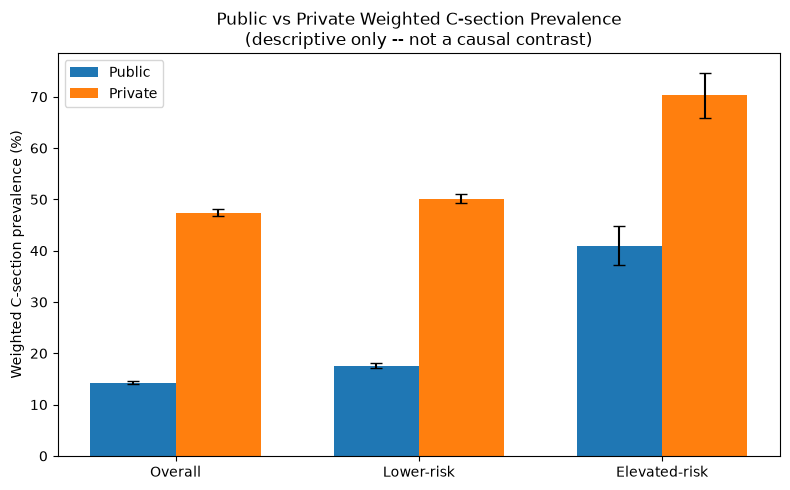

Saved figure to ..\..\outputs\figures\b1_public_private_prevalence.png


In [14]:
import matplotlib.pyplot as plt

plot_rows = [
    ("Overall", facility_table[facility_table["label"] == "public"].iloc[0], facility_table[facility_table["label"] == "private"].iloc[0]),
    ("Lower-risk", facility_by_risk_table.query("label == 'lower_risk__public'").iloc[0], facility_by_risk_table.query("label == 'lower_risk__private'").iloc[0]),
    ("Elevated-risk", facility_by_risk_table.query("label == 'elevated_risk__public'").iloc[0], facility_by_risk_table.query("label == 'elevated_risk__private'").iloc[0]),
]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(plot_rows))
width = 0.35

public_vals = [r[1]["weighted_prevalence_pct"] for r in plot_rows]
public_err = [[r[1]["weighted_prevalence_pct"] - r[1]["ci95_low_pct"] for r in plot_rows],
              [r[1]["ci95_high_pct"] - r[1]["weighted_prevalence_pct"] for r in plot_rows]]
private_vals = [r[2]["weighted_prevalence_pct"] for r in plot_rows]
private_err = [[r[2]["weighted_prevalence_pct"] - r[2]["ci95_low_pct"] for r in plot_rows],
               [r[2]["ci95_high_pct"] - r[2]["weighted_prevalence_pct"] for r in plot_rows]]

ax.bar(x - width/2, public_vals, width, yerr=public_err, capsize=4, label="Public")
ax.bar(x + width/2, private_vals, width, yerr=private_err, capsize=4, label="Private")

ax.set_xticks(x)
ax.set_xticklabels([r[0] for r in plot_rows])
ax.set_ylabel("Weighted C-section prevalence (%)")
ax.set_title("Public vs Private Weighted C-section Prevalence\n(descriptive only -- not a causal contrast)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "b1_public_private_prevalence.png", dpi=200)
plt.show()
print("Saved figure to", FIGURES_DIR / "b1_public_private_prevalence.png")